Theory Questions


1. What is unsupervised learning in the context of machine learning?
Unsupervised learning is a type of machine learning where the algorithm is trained on data that does not have pre-labeled responses or target variables. The goal is to find hidden patterns, structures, or relationships within the input data, such as grouping similar items together (clustering) or reducing the number of variables (dimensionality reduction).

2. How does K-Means clustering algorithm work?
K-Means works through an iterative process:

    Initialization: Choose k initial centroids randomly.

    Assignment: Assign each data point to the nearest centroid based on Euclidean distance.

    Update: Calculate the new mean of each cluster and move the centroid to that mean.

    Repeat: Continue steps 2 and 3 until the centroids no longer move significantly or a maximum number of iterations is reached.

3. Explain the concept of a dendrogram in hierarchical clustering?
A dendrogram is a tree-like diagram used to visualize the arrangement of the clusters produced by hierarchical clustering. The y-axis represents the distance (dissimilarity) between clusters, and the x-axis shows the individual data points. By "cutting" the dendrogram at a specific height, you can determine the number of clusters for your dataset.

4. What is the main difference between K-Means and Hierarchical Clustering?
The primary difference is the structure and flexibility:

    K-Means: Requires you to specify the number of clusters (k) upfront and produces flat, non-overlapping partitions.

    Hierarchical: Does not require k beforehand; it builds a hierarchy of clusters (a tree) and allows you to choose the level of granularity later.

5. What are the advantages of DBSCAN over K-Means?
DBSCAN (Density-Based Spatial Clustering of Applications with Noise) offers two major perks:

    It can identify clusters of arbitrary shapes (e.g., crescents), whereas K-Means assumes clusters are spherical.

    It is robust to outliers and can identify noise points that don't belong to any cluster.

6. When would you use Silhouette Score in clustering?
You use Silhouette Score when you need to evaluate the quality of your clusters without having ground-truth labels. It measures how similar an object is to its own cluster compared to other clusters. It is particularly useful for comparing the performance of different algorithms or choosing the optimal k in K-Means.

7. What are the limitations of Hierarchical Clustering?

    Scalability: It has high computational complexity (O(n2) or O(n3)), making it very slow for large datasets.

    No Reversibility: Once a step (merging or splitting) is done, it cannot be undone.

    Sensitivity to Noise: Outliers can negatively impact the tree structure.

8. Why is feature scaling important in clustering algorithms like K-Means?
K-Means is a distance-based algorithm (usually using Euclidean distance). If one feature has a range of 0–1 and another has 0–1,000,000, the larger feature will dominate the distance calculation, making the smaller feature irrelevant. Scaling (like Standardization) ensures all features contribute equally.

9. How does DBSCAN identify noise points?
DBSCAN classifies a point as "noise" if it is not a core point (doesn't have enough neighbors within a radius ϵ) and is not reachable from any core point. Essentially, if a point lives in a low-density region, it's labeled as noise.

10. Define inertia in the context of K-Means.
Inertia (or Within-Cluster Sum of Squares) is the sum of squared distances of samples to their closest cluster center. It measures how internally coherent clusters are. Lower inertia generally means tighter, better-defined clusters.

11. What is the elbow method in K-Means clustering?
The elbow method is a heuristic used to find the optimal number of clusters. You plot the inertia (WCSS) against the number of clusters (k). As k increases, inertia drops. The "elbow" is the point where the rate of decrease shifts from rapid to slow, indicating that adding more clusters provides diminishing returns.

12. Describe the concept of "density" in DBSCAN.
Density is defined by two parameters: Epsilon (ϵ), the maximum distance between two points to be considered neighbors, and MinPts, the minimum number of points required within that radius to form a "dense" region (a core point).

13. Can hierarchical clustering be used on categorical data?
Yes, but you cannot use standard Euclidean distance. You must use a dissimilarity metric appropriate for categorical data (like Gower’s distance or Jaccard similarity) to build the distance matrix before running the algorithm.

14. What does a negative Silhouette Score indicate?
A negative score (near -1) indicates that a data point has been assigned to the wrong cluster, as it is more similar to a neighboring cluster than the one it currently belongs to.

15. Explain the term "linkage criteria" in hierarchical clustering.
Linkage criteria determine how the distance between two sets (clusters) of observations is calculated. Common types include:

    Single Linkage: Distance between the closest points.

    Complete Linkage: Distance between the farthest points.

    Average Linkage: Average distance between all pairs of points.

    Ward’s Linkage: Minimizes the variance within clusters.

16. Why might K-Means clustering perform poorly on data with varying cluster sizes or densities?
K-Means tries to minimize variance, which biases it toward creating spherical clusters of similar size. If one cluster is very dense and small while another is sparse and large, K-Means may split the large cluster or "steal" points from the dense one to balance the distances.

17. What are the core parameters in DBSCAN, and how do they influence clustering?

    Epsilon (ϵ): Determines the neighborhood size. If too small, most points are noise; if too large, clusters merge.

    MinPts: Determines the density threshold. If too small, noise might be labeled as clusters; if too large, valid clusters might be labeled as noise.

18. How does K-Means++ improve upon standard K-Means initialization?
Standard K-Means picks initial centroids purely at random, which can lead to poor convergence or getting stuck in local optima. K-Means++ spreads the initial centroids out by choosing the first center randomly and then choosing subsequent centers with a probability proportional to their squared distance from the nearest existing center.

19. What is agglomerative clustering?
Agglomerative clustering is the most common type of hierarchical clustering. It is a "bottom-up" approach where each data point starts in its own cluster, and pairs of clusters are successively merged as one moves up the hierarchy until only one cluster remains.

20. What makes Silhouette Score a better metric than just inertia for model evaluation?
Inertia only measures how tight clusters are, but it always decreases as you add more clusters (even if the clusters aren't meaningful). Silhouette Score considers both cohesion (how close a point is to its own cluster) and separation (how far it is from other clusters), providing a more balanced view of cluster quality.

Practical Questions

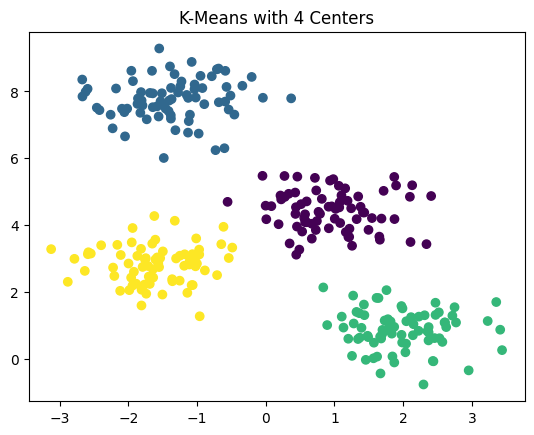

In [2]:
#21. Generate synthetic data with 4 centers using make_blobs and apply K-Means clustering. Visualize using a scatter plot.
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)
kmeans = KMeans(n_clusters=4)
kmeans.fit(X)

plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='viridis')
plt.title("K-Means with 4 Centers")
plt.show()

In [4]:
#22. Load the Iris dataset and use Agglomerative Clustering to group the data into 3 clusters. Display the first 10 predicted labels.
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering

iris = load_iris()
agg_clustering = AgglomerativeClustering(n_clusters=3)
labels = agg_clustering.fit_predict(iris.data)
print(f"First 10 labels: {labels[:10]}")

First 10 labels: [1 1 1 1 1 1 1 1 1 1]


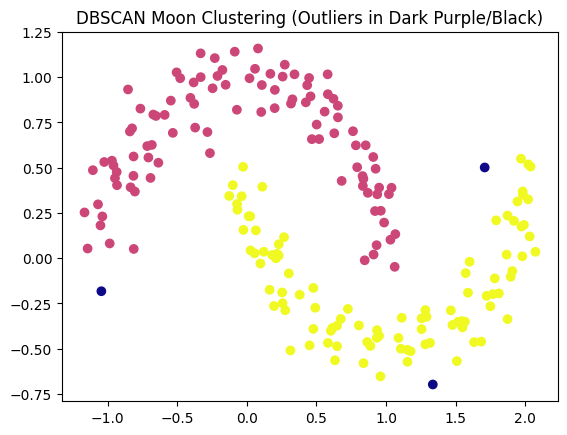

In [3]:
#23. Generate synthetic data using make_moons and apply DBSCAN. Highlight outliers in the plot.
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN

X, _ = make_moons(n_samples=200, noise=0.1, random_state=0)
dbscan = DBSCAN(eps=0.2, min_samples=5)
labels = dbscan.fit_predict(X)

# Outliers are labeled as -1 in DBSCAN
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='plasma')
plt.title("DBSCAN Moon Clustering (Outliers in Dark Purple/Black)")
plt.show()

In [5]:
#24. Load the Wine dataset and apply K-Means clustering after standardizing the features. Print the size of each cluster.
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
import pandas as pd

wine = load_wine()
X_scaled = StandardScaler().fit_transform(wine.data)
kmeans = KMeans(n_clusters=3, random_state=42).fit(X_scaled)

print(pd.Series(kmeans.labels_).value_counts())

0    65
2    62
1    51
Name: count, dtype: int64


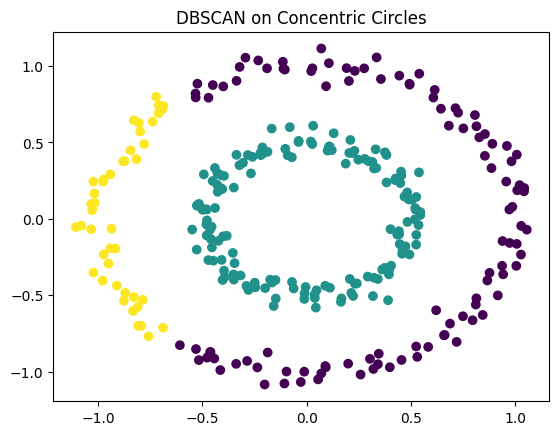

In [6]:
#25. Use make_circles to generate synthetic data and cluster it using DBSCAN. Plot the result.

In [8]:
#26. Load the Breast Cancer dataset, apply MinMaxScaler, and use K-Means with 2 clusters. Output the cluster centroids
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import MinMaxScaler

data = load_breast_cancer()
X_scaled = MinMaxScaler().fit_transform(data.data)
kmeans = KMeans(n_clusters=2).fit(X_scaled)
print("Cluster Centroids:\n", kmeans.cluster_centers_)

Cluster Centroids:
 [[0.25535358 0.28833455 0.24696416 0.14388369 0.35743076 0.18019471
  0.10344776 0.1306603  0.34011829 0.25591606 0.06427485 0.18843043
  0.05975663 0.02870108 0.18158628 0.13242941 0.05821528 0.18069336
  0.17221057 0.08403996 0.2052406  0.32069002 0.19242138 0.09943446
  0.3571115  0.14873935 0.13142287 0.26231363 0.22639412 0.15437354]
 [0.50483563 0.39560329 0.50578661 0.36376576 0.46988732 0.42226302
  0.41838662 0.46928035 0.45899738 0.29945886 0.19093085 0.19112073
  0.17903433 0.13086432 0.18017962 0.25890126 0.12542475 0.30942779
  0.190072   0.13266975 0.48047448 0.45107371 0.4655302  0.31460597
  0.49868817 0.36391461 0.39027292 0.65827197 0.33752296 0.26041387]]


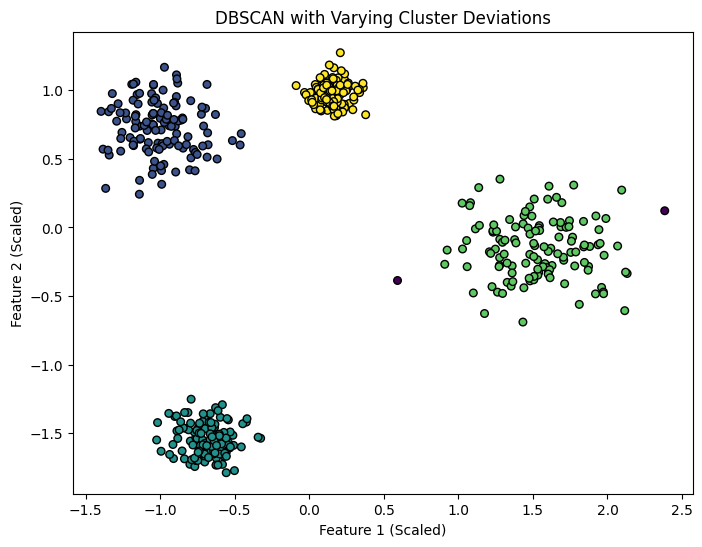

In [9]:
#27. Generate synthetic data using make_blobs with varying cluster standard deviations and cluster with DBSCAN.
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# 1. Generate synthetic data with different standard deviations (e.g., 0.5, 1.5, 0.7, 1.2)
X, y = make_blobs(n_samples=500,
                  centers=4,
                  cluster_std=[0.5, 1.5, 0.7, 1.2],
                  random_state=42)

# 2. Standardize features (DBSCAN is very sensitive to scale)
X = StandardScaler().fit_transform(X)

# 3. Apply DBSCAN
# eps is the maximum distance between two samples for one to be considered as in the neighborhood of the other.
dbscan = DBSCAN(eps=0.3, min_samples=5)
labels = dbscan.fit_predict(X)

# 4. Plot the result
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', marker='o', s=30, edgecolors='k')
plt.title("DBSCAN with Varying Cluster Deviations")
plt.xlabel("Feature 1 (Scaled)")
plt.ylabel("Feature 2 (Scaled)")
plt.show()

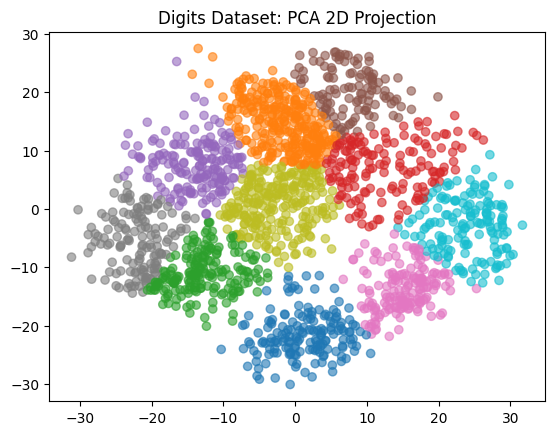

In [10]:
#28. Load the Digits dataset, reduce it to 2D using PCA, and visualize clusters from K-Means.
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

digits = load_digits()
pca = PCA(n_components=2)
X_pca = pca.fit_transform(digits.data)

kmeans = KMeans(n_clusters=10)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans.fit_predict(X_pca), cmap='tab10', alpha=0.6)
plt.title("Digits Dataset: PCA 2D Projection")
plt.show()

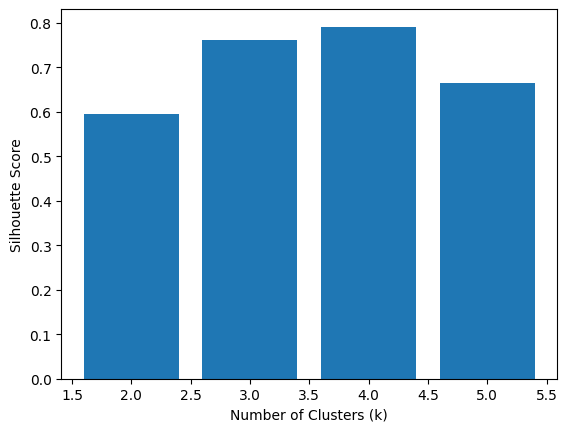

In [11]:
#29. Create synthetic data using make_blobs and evaluate silhouette scores for $k=2$ to $5$. Display as a bar chart.
from sklearn.metrics import silhouette_score

X, _ = make_blobs(n_samples=500, centers=4, random_state=42)
scores = []
ks = [2, 3, 4, 5]

for k in ks:
    labels = KMeans(n_clusters=k).fit_predict(X)
    scores.append(silhouette_score(X, labels))

plt.bar(ks, scores)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

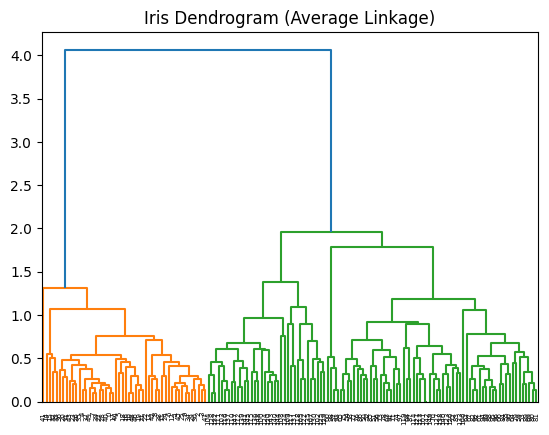

In [12]:
#30. Load the Iris dataset and use hierarchical clustering to group data. Plot a dendrogram with average linkage.
from scipy.cluster.hierarchy import dendrogram, linkage

iris = load_iris()
linked = linkage(iris.data, 'average')
dendrogram(linked)
plt.title("Iris Dendrogram (Average Linkage)")
plt.show()

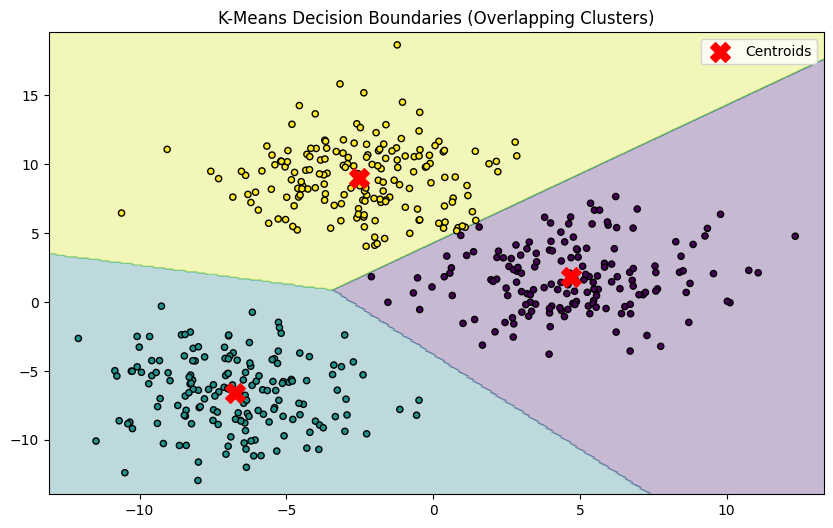

In [13]:
#31. Generate synthetic data with overlapping clusters using make_blobs, then apply K-Means and visualize with decision boundaries.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# 1. Generate synthetic data with overlapping clusters (higher cluster_std = more overlap)
X, y = make_blobs(n_samples=500, centers=3, cluster_std=2.5, random_state=42)

# 2. Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

# 3. Create a mesh grid to plot the decision boundaries
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# 4. Predict across the entire mesh grid
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 5. Plotting
plt.figure(figsize=(10, 6))
# Plot the decision regions
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
# Plot the data points
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, s=20, edgecolor='k', cmap='viridis')
# Plot the centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, marker='X', c='red', label='Centroids')

plt.title("K-Means Decision Boundaries (Overlapping Clusters)")
plt.legend()
plt.show()

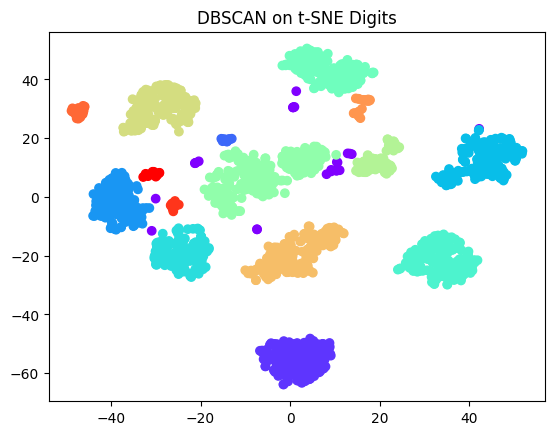

In [14]:
#32. Load the Digits dataset and apply DBSCAN after reducing dimensions with t-SNE. Visualize the results.
from sklearn.manifold import TSNE

X_tsne = TSNE(n_components=2).fit_transform(digits.data)
dbscan = DBSCAN(eps=3, min_samples=10) # Parameters vary based on t-SNE scale
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=dbscan.fit_predict(X_tsne), cmap='rainbow')
plt.title("DBSCAN on t-SNE Digits")
plt.show()

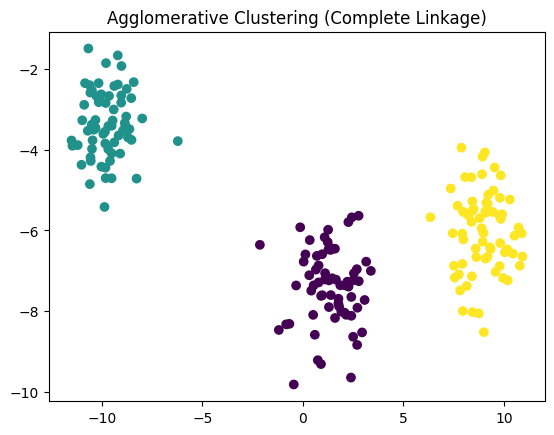

In [15]:
#33. Generate synthetic data using make_blobs and apply Agglomerative Clustering with complete linkage. Plot the result.
X, _ = make_blobs(n_samples=200, centers=3)
agg = AgglomerativeClustering(n_clusters=3, linkage='complete')
plt.scatter(X[:, 0], X[:, 1], c=agg.fit_predict(X))
plt.title("Agglomerative Clustering (Complete Linkage)")
plt.show()

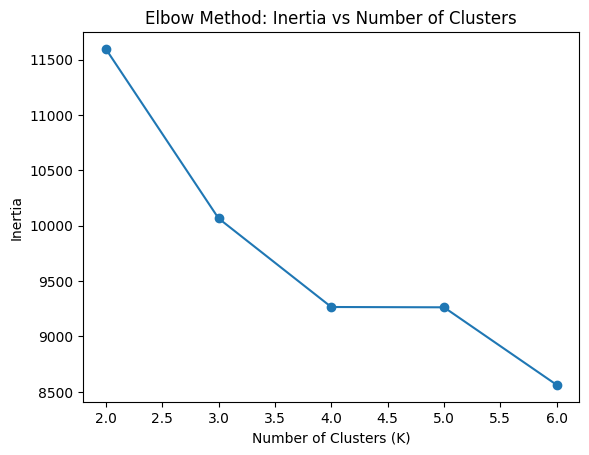

In [16]:
#34. Load the Breast Cancer dataset and compare inertia values for K = 2 to 6 using K-Means. Show results in a line plot.
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()
X = StandardScaler().fit_transform(data.data)
inertia = []
K_range = range(2, 7)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method: Inertia vs Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

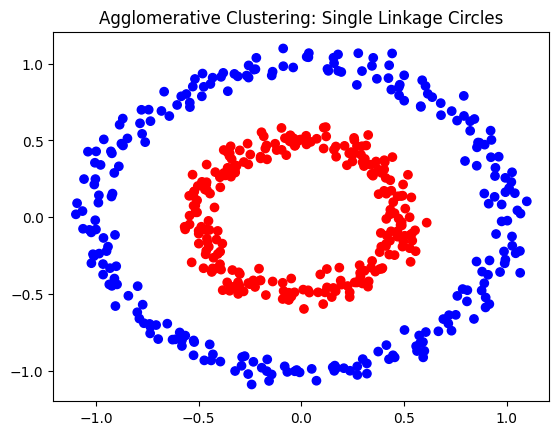

In [17]:
#35. Generate synthetic concentric circles using make_circles and cluster using Agglomerative Clustering with single linkage.
from sklearn.datasets import make_circles
from sklearn.cluster import AgglomerativeClustering

X, _ = make_circles(n_samples=500, factor=0.5, noise=0.05)
# 'single' linkage is key for non-spherical shapes
agg = AgglomerativeClustering(n_clusters=2, linkage='single')
plt.scatter(X[:, 0], X[:, 1], c=agg.fit_predict(X), cmap='bwr')
plt.title("Agglomerative Clustering: Single Linkage Circles")
plt.show()

In [18]:
#36. Use the Wine dataset, apply DBSCAN after scaling the data, and count the number of clusters (excluding noise).
from sklearn.datasets import load_wine
from sklearn.cluster import DBSCAN
import numpy as np

wine = load_wine()
X = StandardScaler().fit_transform(wine.data)
dbscan = DBSCAN(eps=2.5, min_samples=5).fit(X)

# Labels of -1 represent noise. We use set() to find unique labels.
labels = dbscan.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"Number of clusters (excluding noise): {n_clusters}")

Number of clusters (excluding noise): 1


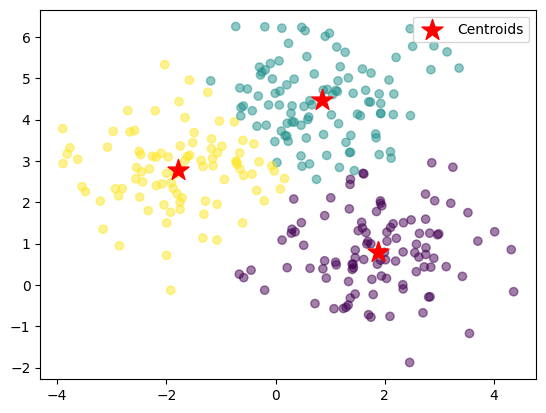

In [19]:
#37. Generate synthetic data with make_blobs and apply KMeans. Then plot the cluster centers on top of the data points.
X, _ = make_blobs(n_samples=300, centers=3, random_state=0)
kmeans = KMeans(n_clusters=3).fit(X)

plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, alpha=0.5)
# Plotting the centroids as large red markers
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=250, c='red', marker='*', label='Centroids')
plt.legend()
plt.show()

In [20]:
#38. Load the Iris dataset, cluster with DBSCAN, and print how many samples were identified as noise.
from sklearn.datasets import load_iris

iris = load_iris()
X = StandardScaler().fit_transform(iris.data)
dbscan = DBSCAN(eps=0.5, min_samples=5).fit(X)

noise_count = list(dbscan.labels_).count(-1)
print(f"Number of noise samples: {noise_count}")

Number of noise samples: 34


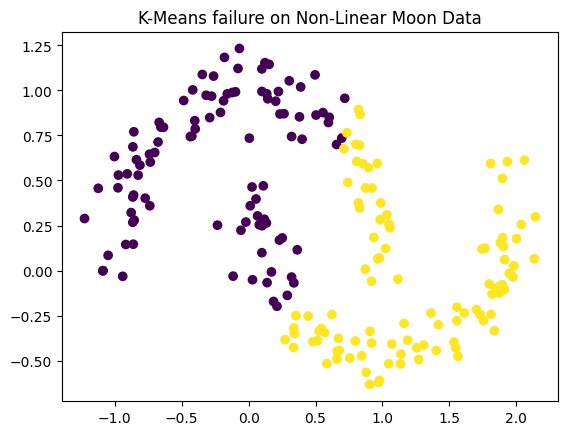

In [21]:
#39. Generate synthetic non-linearly separable data using make_moons, apply K-Means, and visualize the clustering result.
from sklearn.datasets import make_moons

X, _ = make_moons(n_samples=200, noise=0.1, random_state=42)
kmeans = KMeans(n_clusters=2).fit(X)

plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='viridis')
plt.title("K-Means failure on Non-Linear Moon Data")
plt.show()

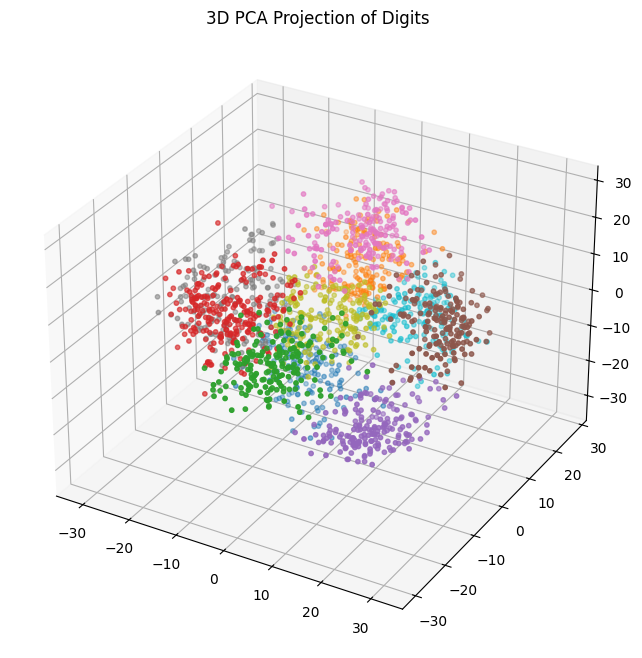

In [23]:
#40. Load the Digits dataset, apply PCA to reduce to 3 components, then use KMeans and visualize with a 3D scatter plot.
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

digits = load_digits()
pca = PCA(n_components=3)
X_3D = pca.fit_transform(digits.data)

kmeans = KMeans(n_clusters=10, random_state=0).fit(X_3D)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_3D[:, 0], X_3D[:, 1], X_3D[:, 2], c=kmeans.labels_, cmap='tab10', s=10)
ax.set_title("3D PCA Projection of Digits")
plt.show()

In [24]:
#41. Generate synthetic blobs with 5 centers and apply KMeans. Then use silhouette_score to evaluate the clustering.
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X, _ = make_blobs(n_samples=500, centers=5, random_state=42)
kmeans = KMeans(n_clusters=5, random_state=42).fit(X)
score = silhouette_score(X, kmeans.labels_)

print(f"Silhouette Score for 5 clusters: {score:.4f}")

Silhouette Score for 5 clusters: 0.6787


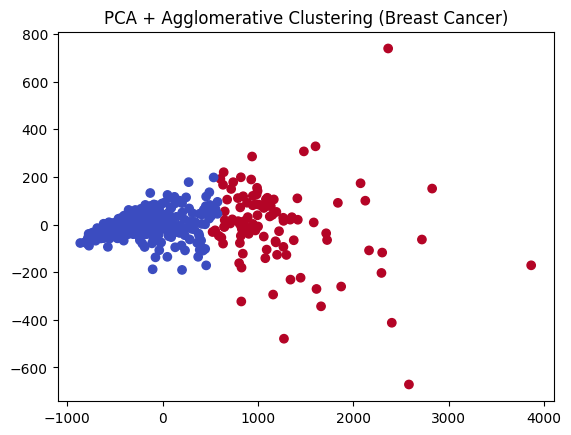

In [25]:
#42. Load the Breast Cancer dataset, reduce dimensionality using PCA, and apply Agglomerative Clustering. Visualize in 2D.
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

data = load_breast_cancer()
X_pca = PCA(n_components=2).fit_transform(data.data)
agg = AgglomerativeClustering(n_clusters=2).fit_predict(X_pca)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg, cmap='coolwarm')
plt.title("PCA + Agglomerative Clustering (Breast Cancer)")
plt.show()

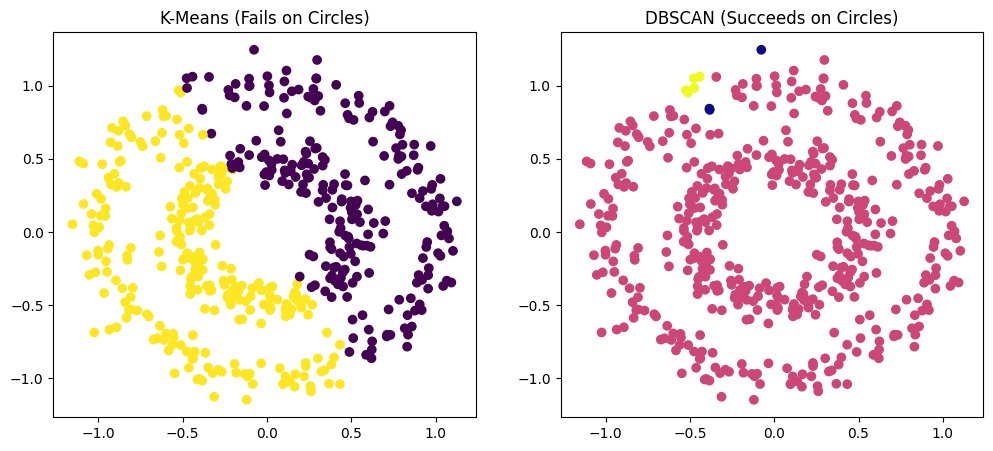

In [26]:
#43. Generate noisy circular data using make_circles and visualize clustering results from KMeans and DBSCAN side-by-side.
from sklearn.datasets import make_circles
from sklearn.cluster import DBSCAN

X, _ = make_circles(n_samples=500, factor=0.5, noise=0.08, random_state=42)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# KMeans
km_labels = KMeans(n_clusters=2).fit_predict(X)
ax1.scatter(X[:, 0], X[:, 1], c=km_labels, cmap='viridis')
ax1.set_title("K-Means (Fails on Circles)")

# DBSCAN
db_labels = DBSCAN(eps=0.15, min_samples=5).fit_predict(X)
ax2.scatter(X[:, 0], X[:, 1], c=db_labels, cmap='plasma')
ax2.set_title("DBSCAN (Succeeds on Circles)")
plt.show()

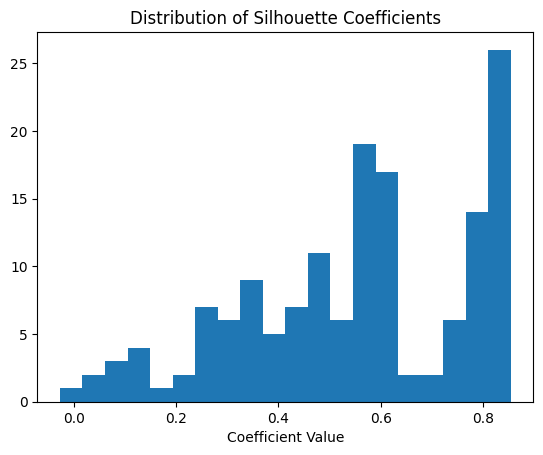

In [27]:
#44. Load the Iris dataset and plot the Silhouette Coefficient for each sample after KMeans clustering.
from sklearn.metrics import silhouette_samples
import numpy as np

iris = load_iris()
kmeans = KMeans(n_clusters=3, random_state=42).fit(iris.data)
sample_silhouette_values = silhouette_samples(iris.data, kmeans.labels_)

plt.hist(sample_silhouette_values, bins=20)
plt.title("Distribution of Silhouette Coefficients")
plt.xlabel("Coefficient Value")
plt.show()

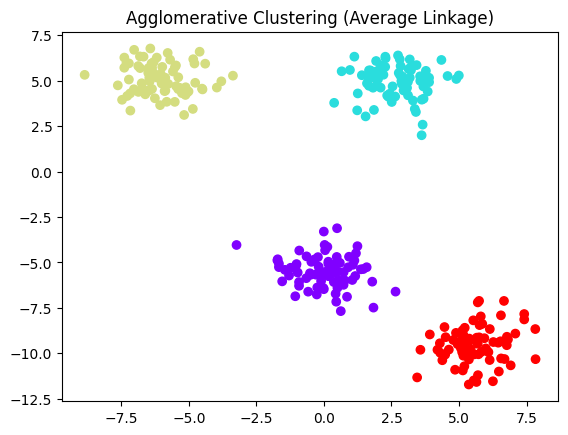

In [28]:
#45. Generate synthetic data using make_blobs and apply Agglomerative Clustering with 'average' linkage. Visualize clusters.
X, _ = make_blobs(n_samples=300, centers=4, random_state=10)
agg = AgglomerativeClustering(n_clusters=4, linkage='average')
plt.scatter(X[:, 0], X[:, 1], c=agg.fit_predict(X), cmap='rainbow')
plt.title("Agglomerative Clustering (Average Linkage)")
plt.show()

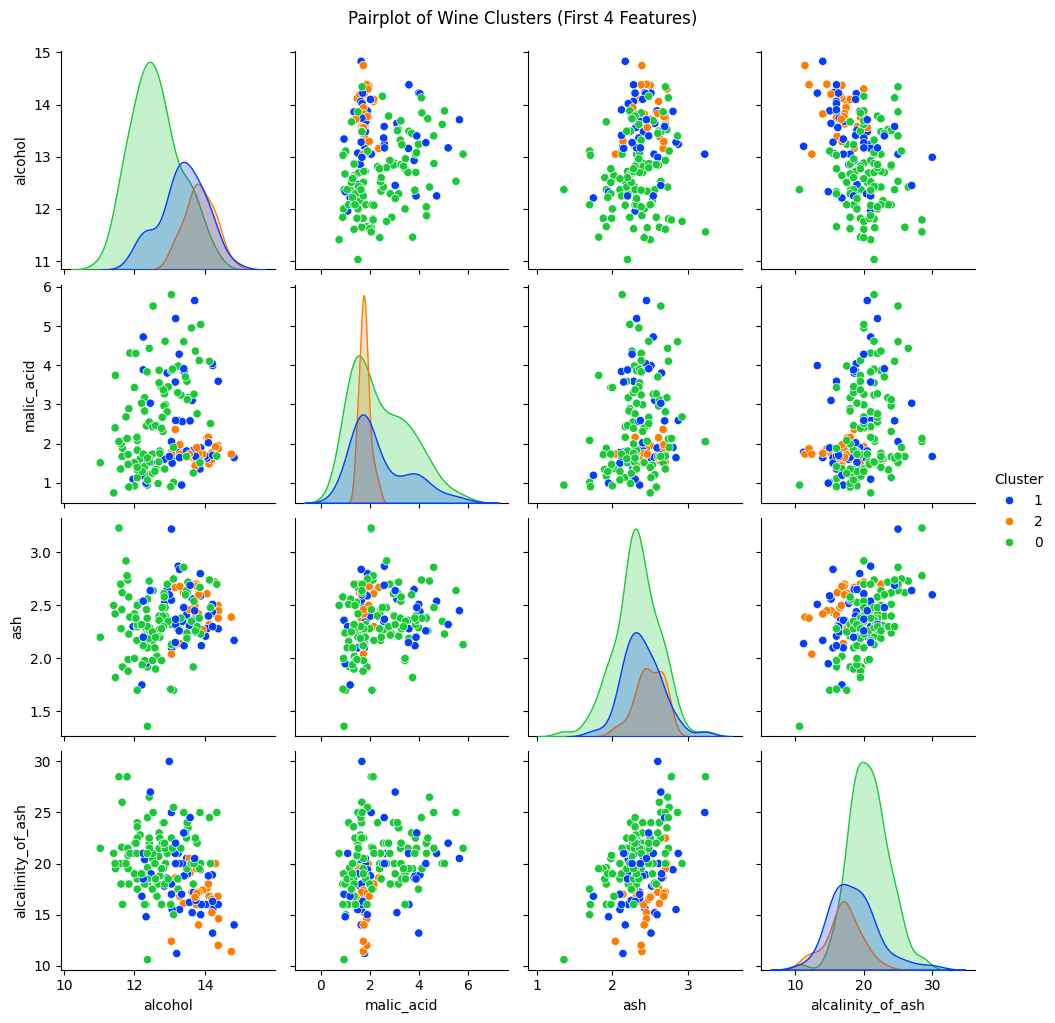

In [29]:
#46. Load the Wine dataset, apply KMeans, and visualize the cluster assignments in a seaborn pairplot (first 4 features).
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_wine

wine = load_wine()
kmeans = KMeans(n_clusters=3, random_state=42).fit(wine.data)

df = pd.DataFrame(wine.data[:, :4], columns=wine.feature_names[:4])
df['Cluster'] = kmeans.labels_.astype(str)

sns.pairplot(df, hue='Cluster', palette='bright')
plt.suptitle("Pairplot of Wine Clusters (First 4 Features)", y=1.02)
plt.show()

In [30]:
#47. Generate noisy blobs using make_blobs and use DBSCAN to identify both clusters and noise points. Print the count.
X, _ = make_blobs(n_samples=400, centers=3, cluster_std=1.0, random_state=42)
# Adding manual noise
noise = np.random.uniform(low=-10, high=10, size=(20, 2))
X = np.vstack([X, noise])

db = DBSCAN(eps=1.0, min_samples=5).fit(X)
labels = db.labels_

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print(f"Estimated number of clusters: {n_clusters_}")
print(f"Estimated number of noise points: {n_noise_}")

Estimated number of clusters: 3
Estimated number of noise points: 20


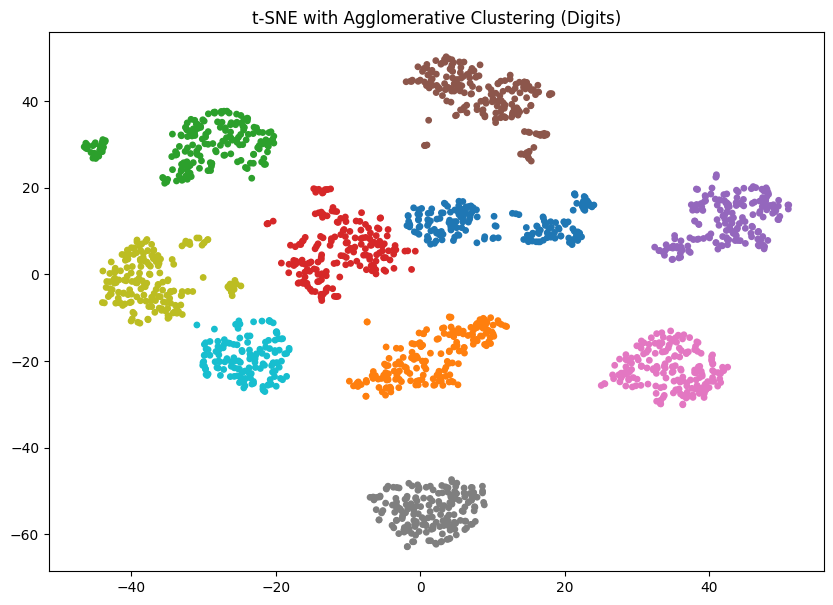

In [31]:
#48. Load the Digits dataset, reduce dimensions using t-SNE, then apply Agglomerative Clustering and plot the clusters.
from sklearn.manifold import TSNE
from sklearn.datasets import load_digits

digits = load_digits()
X_tsne = TSNE(n_components=2, random_state=42).fit_transform(digits.data)
agg_labels = AgglomerativeClustering(n_clusters=10).fit_predict(X_tsne)

plt.figure(figsize=(10, 7))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=agg_labels, cmap='tab10', s=15)
plt.title("t-SNE with Agglomerative Clustering (Digits)")
plt.show()